# Linear Regression — Paddy Crop Yield Prediction

## Module 03 · ML Foundations | End-to-End Regression Pipeline

Predicting total paddy yield (kg) from 44 agricultural features including
soil type, fertiliser inputs, rainfall, temperature, and humidity across
the full crop growth cycle.

In [2]:
#Let's add required imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')


In [4]:
#Load the data
df = pd.read_csv('paddydataset.csv')

#clean column names: strip trailing spaces
df.columns = df.columns.str.strip()

print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
df.head()

Shape: (2789, 45)
Missing values: 0


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [6]:
#stats
print(df.dtypes)
print()
df.describe().round(2)

Hectares                                int64
Agriblock                              object
Variety                                object
Soil Types                             object
Seedrate(in Kg)                         int64
LP_Mainfield(in Tonnes)               float64
Nursery                                object
Nursery area (Cents)                    int64
LP_nurseryarea(in Tonnes)               int64
DAP_20days                              int64
Weed28D_thiobencarb                     int64
Urea_40Days                           float64
Potassh_50Days                        float64
Micronutrients_70Days                   int64
Pest_60Day(in ml)                       int64
30DRain( in mm)                       float64
30DAI(in mm)                          float64
30_50DRain( in mm)                    float64
30_50DAI(in mm)                       float64
51_70DRain(in mm)                     float64
51_70AI(in mm)                        float64
71_105DRain(in mm)                

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,...,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00,2789.00
mean,3.72,92.94,46.47,74.35,3.72,148.70,7.43,100.85,38.59,55.76,...,7.23,8.51,8.17,9.45,76.26,87.59,85.16,83.86,335.51,22517.73
std,1.44,35.94,17.97,28.76,1.44,57.51,2.88,39.01,14.92,21.57,...,2.57,3.20,1.99,2.52,8.00,6.78,3.49,3.13,134.31,9199.66
min,1.00,25.00,12.50,20.00,1.00,40.00,2.00,27.13,10.38,15.00,...,4.00,4.00,4.00,6.00,64.60,78.00,81.00,79.00,80.00,5410.00
25%,3.00,75.00,37.50,60.00,3.00,120.00,6.00,81.39,31.14,45.00,...,4.00,6.00,8.00,6.00,72.00,80.00,83.00,81.00,240.00,16389.00
50%,4.00,100.00,50.00,80.00,4.00,160.00,8.00,108.52,41.52,60.00,...,8.00,10.00,8.00,10.00,72.70,91.00,84.00,84.00,360.00,24636.00
75%,5.00,125.00,62.50,100.00,5.00,200.00,10.00,135.65,51.90,75.00,...,10.00,12.00,10.00,12.00,85.00,95.00,88.00,87.00,450.00,31035.00
max,6.00,150.00,75.00,120.00,6.00,240.00,12.00,162.78,62.28,90.00,...,10.00,12.00,10.00,12.00,88.50,96.00,92.00,88.00,600.00,38814.00


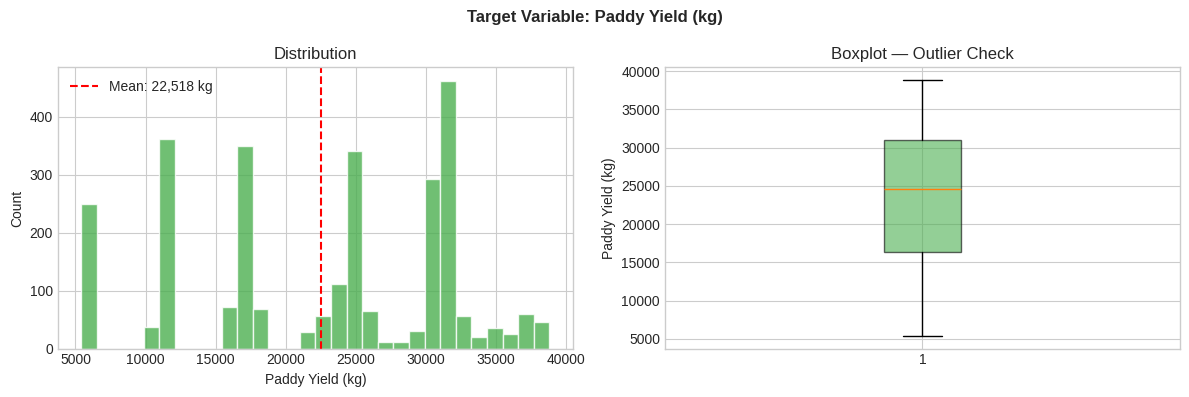

Mean   : 22,518 kg
Median : 24,636 kg
Std    : 9,200 kg
Min    : 5,410 kg
Max    : 38,814 kg


In [7]:
#Let's Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable: Paddy Yield (kg)', fontweight='bold')

# Distribution
axes[0].hist(df['Paddy yield(in Kg)'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Paddy yield(in Kg)'].mean(), color='red', linestyle='--', label=f'Mean: {df["Paddy yield(in Kg)"].mean():,.0f} kg')
axes[0].set_xlabel('Paddy Yield (kg)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Paddy yield(in Kg)'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4CAF50', alpha=0.6))
axes[1].set_ylabel('Paddy Yield (kg)')
axes[1].set_title('Boxplot — Outlier Check')

plt.tight_layout()
plt.show()

print(f'Mean   : {df["Paddy yield(in Kg)"].mean():,.0f} kg')
print(f'Median : {df["Paddy yield(in Kg)"].median():,.0f} kg')
print(f'Std    : {df["Paddy yield(in Kg)"].std():,.0f} kg')
print(f'Min    : {df["Paddy yield(in Kg)"].min():,.0f} kg')
print(f'Max    : {df["Paddy yield(in Kg)"].max():,.0f} kg')

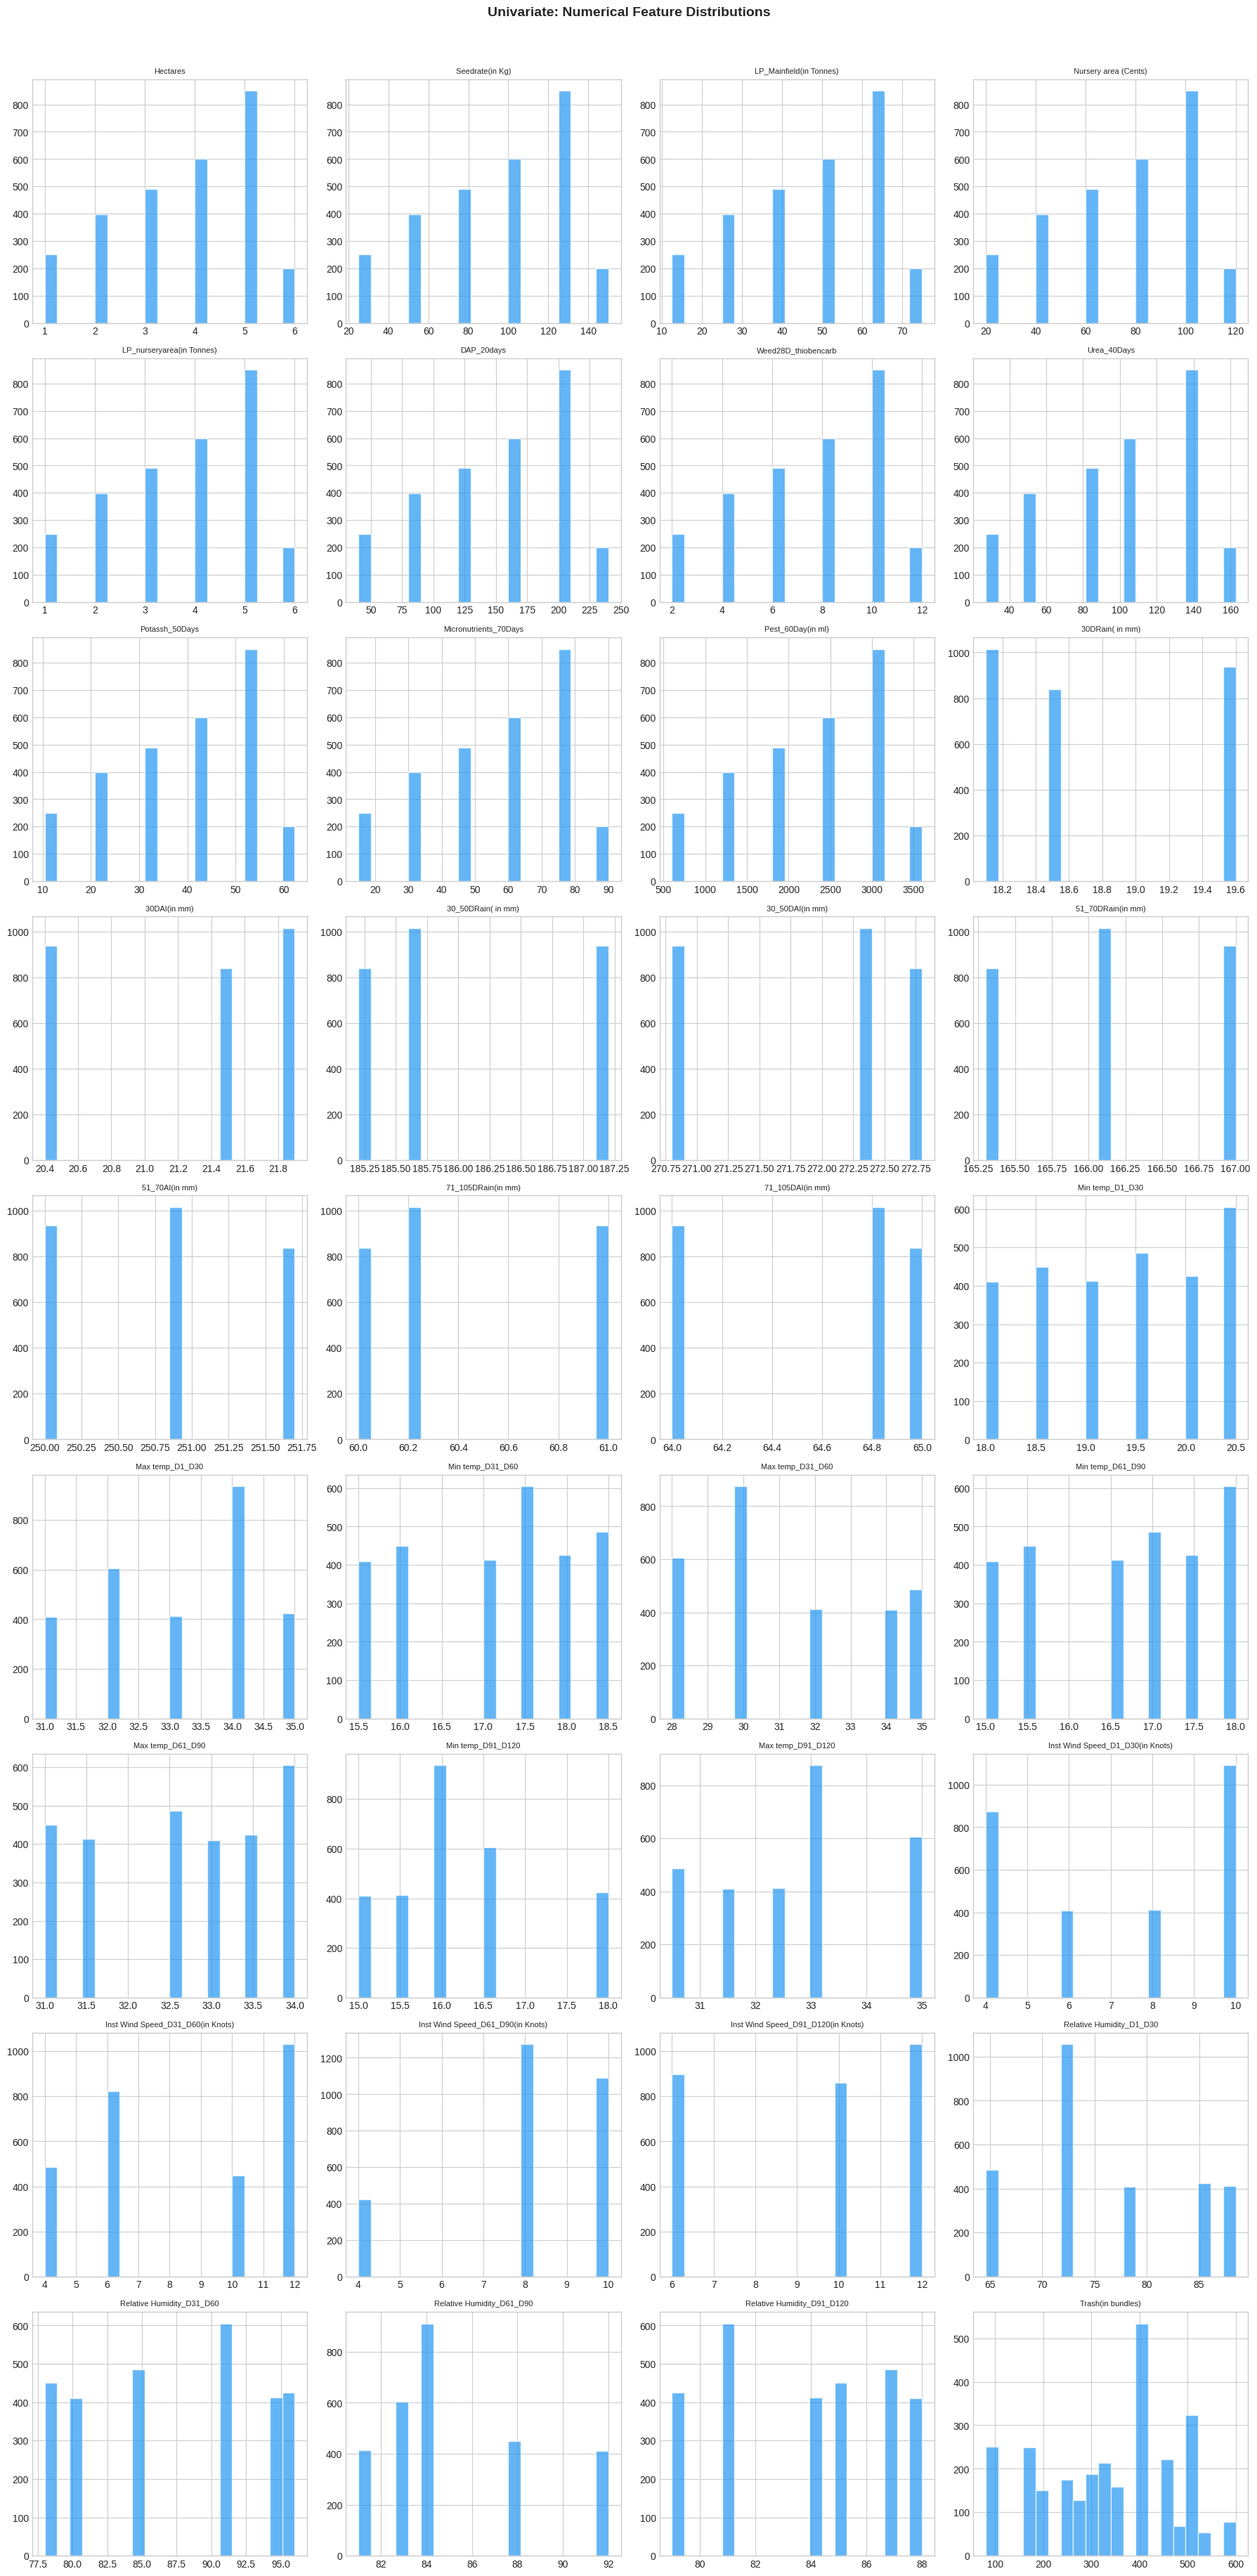

In [10]:
#Univariate: Numerical features distribution

numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('Paddy yield(in Kg)').tolist()

fig, axes = plt.subplots(len(numerical_cols)//4 + 1, 4, figsize=(18, 40))
axes = axes.flat

for ax, col in zip(axes, numerical_cols):
    ax.hist(df[col], bins=20, color='#2196F3', edgecolor='white', alpha=0.7)
    ax.set_title(col, fontsize=8)
    ax.set_xlabel('')

# Hide empty subplots
for ax in axes[len(numerical_cols):]:
    ax.set_visible(False)

plt.suptitle('Univariate: Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

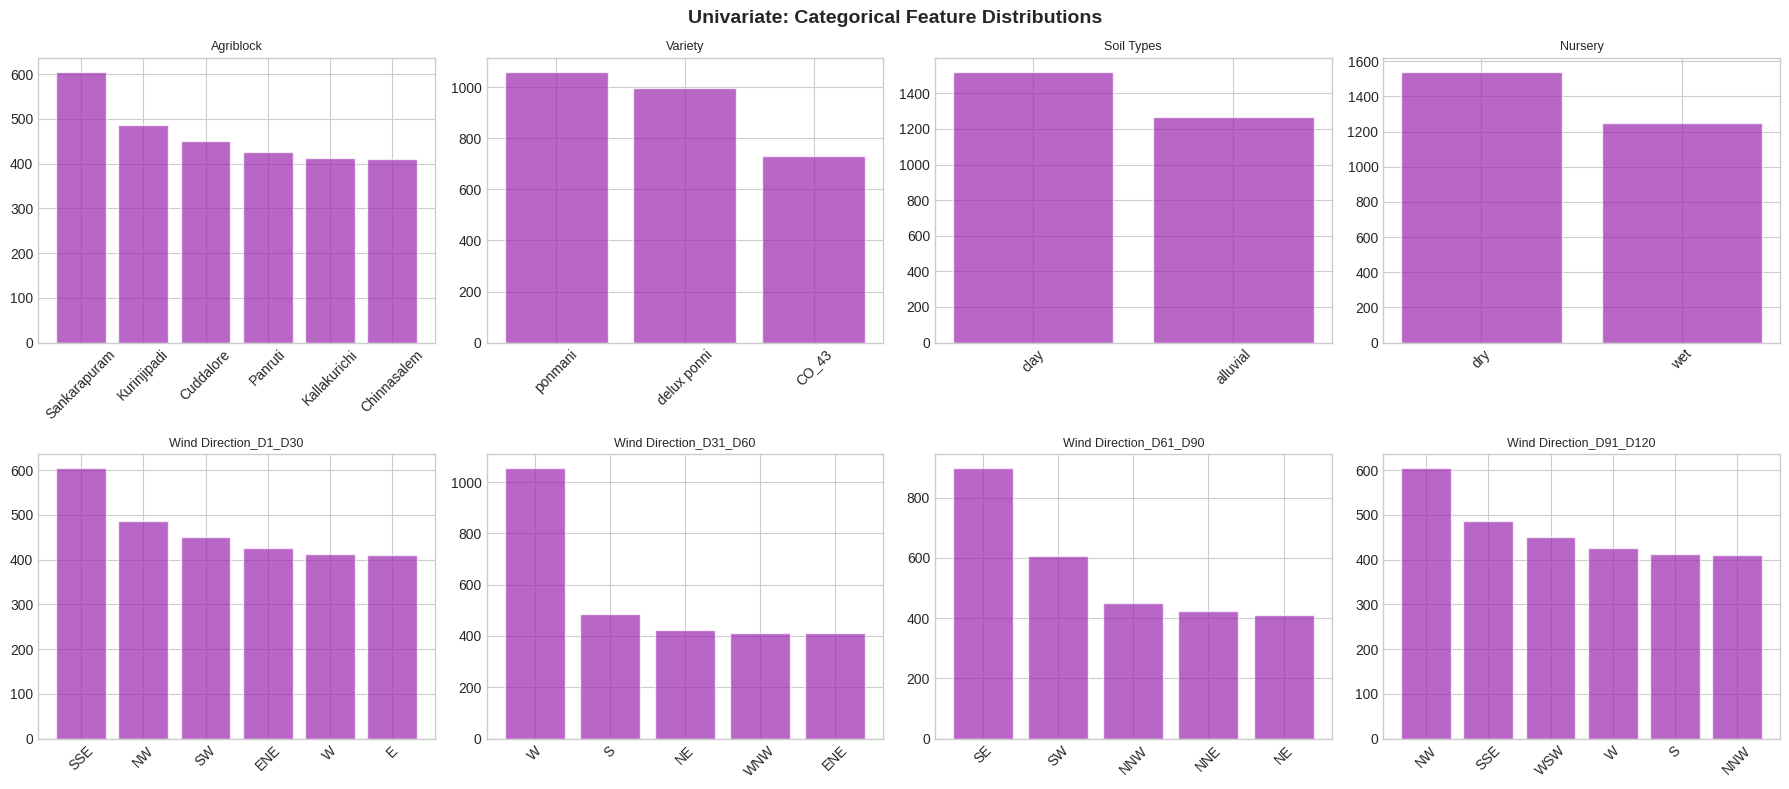

In [11]:
#Univariate: Categorical features
cat_cols = ['Agriblock', 'Variety', 'Soil Types', 'Nursery',
            'Wind Direction_D1_D30', 'Wind Direction_D31_D60',
            'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Univariate: Categorical Feature Distributions', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='#9C27B0', alpha=0.7, edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

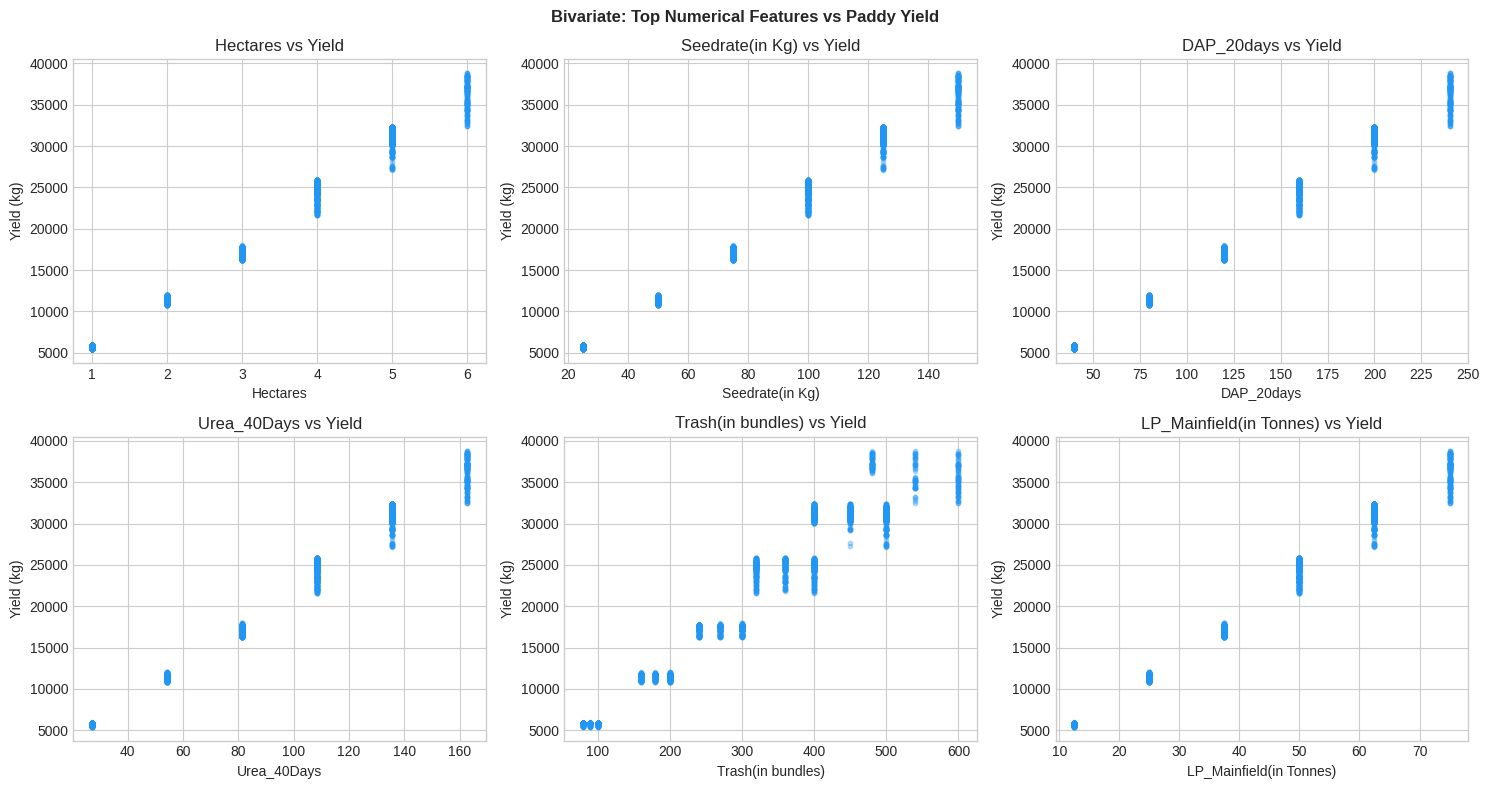

In [12]:
#Bivariate: Numerical features vs Yield
# Top correlated numerical features vs target
top_features = ['Hectares', 'Seedrate(in Kg)', 'DAP_20days',
                'Urea_40Days', 'Trash(in bundles)', 'LP_Mainfield(in Tonnes)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Bivariate: Top Numerical Features vs Paddy Yield', fontweight='bold')

for ax, feat in zip(axes.flat, top_features):
    ax.scatter(df[feat], df['Paddy yield(in Kg)'],
               alpha=0.3, s=10, color='#2196F3')
    ax.set_xlabel(feat)
    ax.set_ylabel('Yield (kg)')
    ax.set_title(f'{feat} vs Yield')

plt.tight_layout()
plt.show()

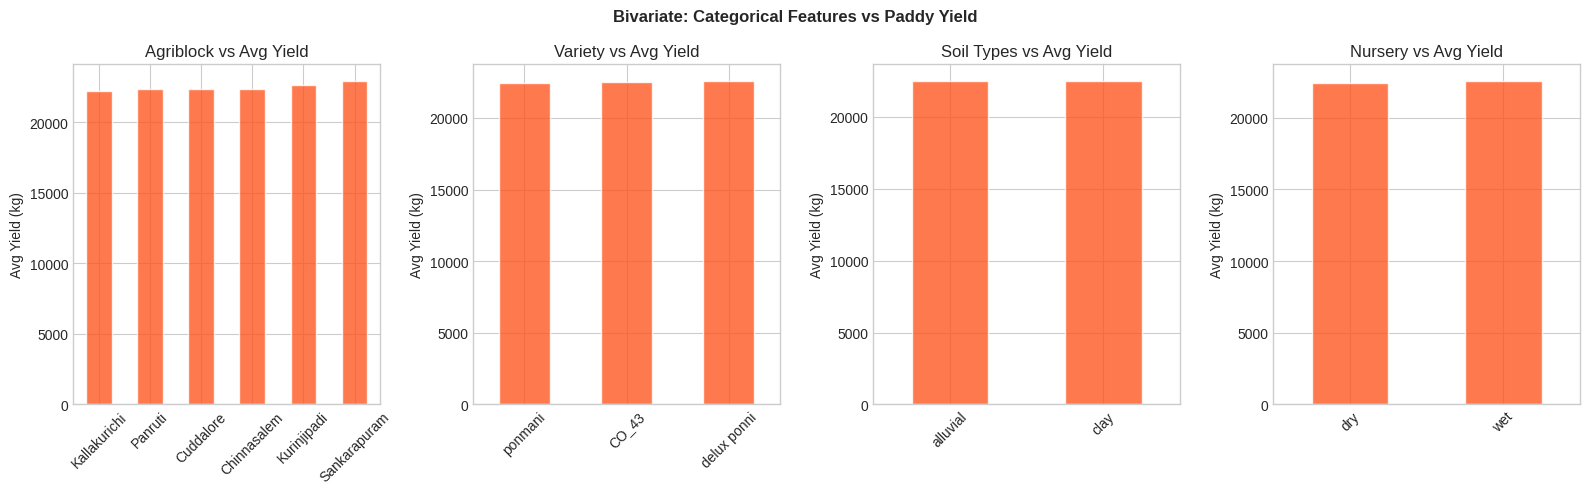

In [13]:
#Bivariate: Categorical features vs Yield
cat_cols = ['Agriblock', 'Variety', 'Soil Types', 'Nursery']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Bivariate: Categorical Features vs Paddy Yield', fontweight='bold')

for ax, col in zip(axes.flat, cat_cols):
    df.groupby(col)['Paddy yield(in Kg)'].mean().sort_values().plot(
        kind='bar', ax=ax, color='#FF5722', alpha=0.8, edgecolor='white')
    ax.set_title(f'{col} vs Avg Yield')
    ax.set_xlabel('')
    ax.set_ylabel('Avg Yield (kg)')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

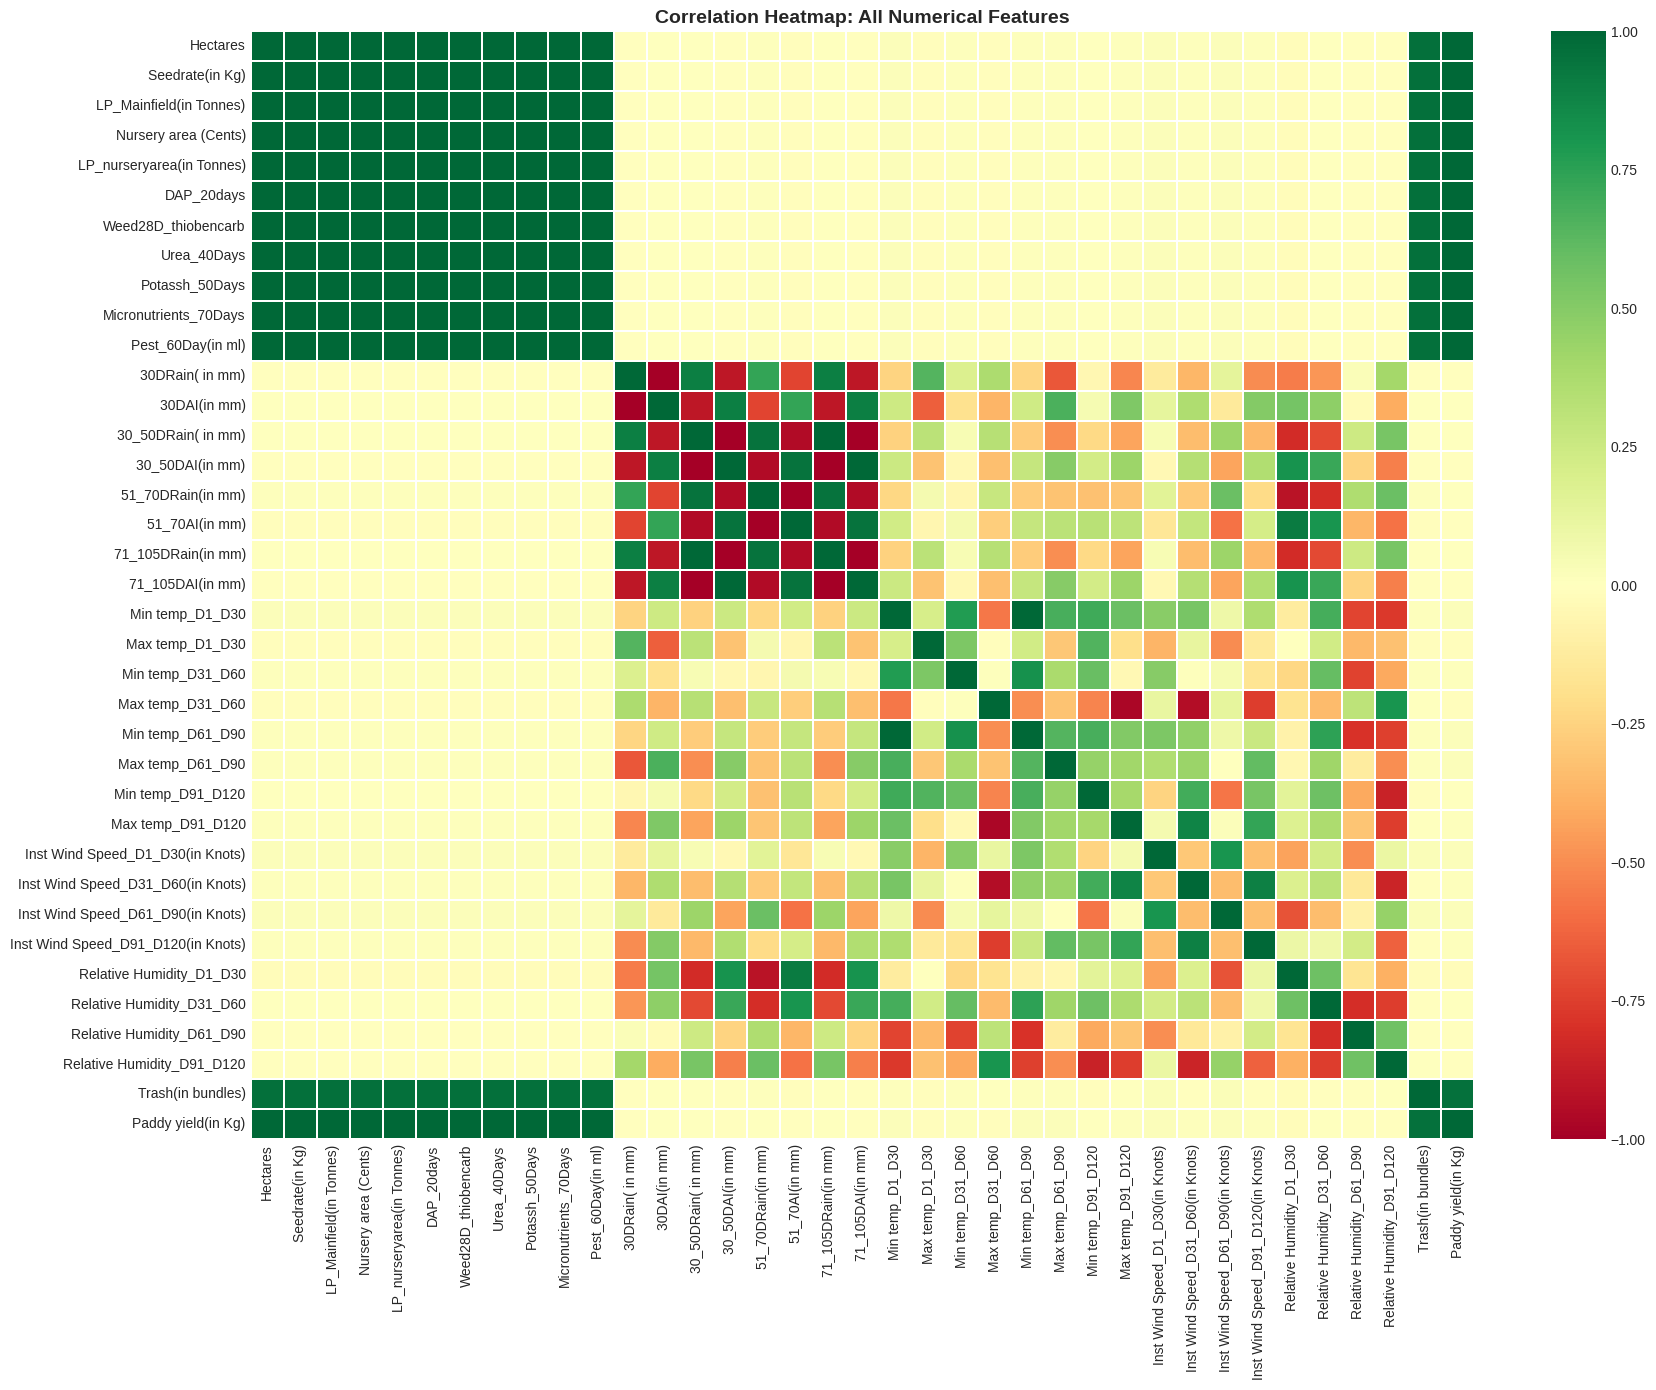

Top 10 features correlated with Paddy Yield:
Urea_40Days                  0.995
Hectares                     0.995
LP_nurseryarea(in Tonnes)    0.995
Weed28D_thiobencarb          0.995
Potassh_50Days               0.995
DAP_20days                   0.995
Nursery area (Cents)         0.995
Micronutrients_70Days        0.995
LP_Mainfield(in Tonnes)      0.995
Seedrate(in Kg)              0.995
Name: Paddy yield(in Kg), dtype: float64

Bottom 5 (negative correlation):
Relative Humidity_D61_D90   -0.007
51_70AI(in mm)              -0.008
Max temp_D1_D30             -0.010
Max temp_D31_D60            -0.011
Relative Humidity_D1_D30    -0.016
Name: Paddy yield(in Kg), dtype: float64


In [8]:
#Let's check Correlation heatmap
plt.figure(figsize=(18, 14))
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix,
            cmap='RdYlGn',
            center=0,
            annot=False,
            linewidths=0.3,
            square=False)

plt.title('Correlation Heatmap: All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix['Paddy yield(in Kg)'].drop('Paddy yield(in Kg)').sort_values(ascending=False)
print('Top 10 features correlated with Paddy Yield:')
print(target_corr.head(10).round(3))
print('\nBottom 5 (negative correlation):')
print(target_corr.tail(5).round(3))

In [9]:
#Key Insights seen after EDA

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}\n')

for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values → {df[col].unique()[:8]}')

Categorical columns: ['Agriblock', 'Variety', 'Soil Types', 'Nursery', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120']

Agriblock: 6 unique values → ['Cuddalore' 'Kurinjipadi' 'Panruti' 'Kallakurichi' 'Sankarapuram'
 'Chinnasalem']
Variety: 3 unique values → ['CO_43' 'ponmani' 'delux ponni']
Soil Types: 2 unique values → ['alluvial' 'clay']
Nursery: 2 unique values → ['dry' 'wet']
Wind Direction_D1_D30: 6 unique values → ['SW' 'NW' 'ENE' 'W' 'SSE' 'E']
Wind Direction_D31_D60: 5 unique values → ['W' 'S' 'NE' 'WNW' 'ENE']
Wind Direction_D61_D90: 5 unique values → ['NNW' 'SE' 'NNE' 'SW' 'NE']
Wind Direction_D91_D120: 6 unique values → ['WSW' 'SSE' 'W' 'S' 'NW' 'NNW']


In [14]:
# Check outliers using IQR method on numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('Paddy yield(in Kg)').tolist()

outlier_summary = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary.append({'Feature': col, 'Outliers': outliers, 'Lower': round(lower,2), 'Upper': round(upper,2)})

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df[outlier_df['Outliers'] > 0].sort_values('Outliers', ascending=False)
print(f'Features with outliers: {len(outlier_df)}')
print(outlier_df.to_string(index=False))

Features with outliers: 1
                          Feature  Outliers  Lower  Upper
Inst Wind Speed_D61_D90(in Knots)       425    5.0   13.0


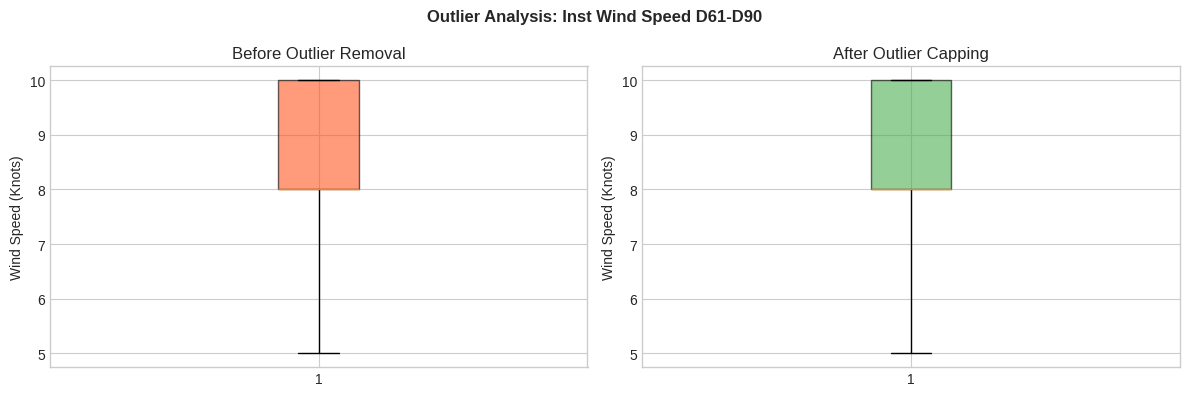

Outliers capped between 5.0 and 13.0


In [16]:
#Visualise and handle the outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Outlier Analysis: Inst Wind Speed D61-D90', fontweight='bold')

# Before
axes[0].boxplot(df['Inst Wind Speed_D61_D90(in Knots)'], patch_artist=True,
                boxprops=dict(facecolor='#FF5722', alpha=0.6))
axes[0].set_title('Before Outlier Removal')
axes[0].set_ylabel('Wind Speed (Knots)')

# Cap outliers using IQR bounds
Q1 = df['Inst Wind Speed_D61_D90(in Knots)'].quantile(0.25)
Q3 = df['Inst Wind Speed_D61_D90(in Knots)'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Inst Wind Speed_D61_D90(in Knots)'] = df['Inst Wind Speed_D61_D90(in Knots)'].clip(lower, upper)

# After
axes[1].boxplot(df['Inst Wind Speed_D61_D90(in Knots)'], patch_artist=True,
                boxprops=dict(facecolor='#4CAF50', alpha=0.6))
axes[1].set_title('After Outlier Capping')
axes[1].set_ylabel('Wind Speed (Knots)')

plt.tight_layout()
plt.show()

print(f'Outliers capped between {lower} and {upper}')

In [17]:
# ── Data Preprocessing ────────────────────────────────────────────
# Encode categorical variables so sklearn can process them.
# Binary encoding for 2-value columns, one-hot for multi-value.
# Then split into 80% train / 20% test before any further analysis.
# Binary encode 2-value columns
df['Nursery'] = df['Nursery'].map({'dry': 0, 'wet': 1})
df['Soil Types'] = df['Soil Types'].map({'alluvial': 0, 'clay': 1})

# One-hot encode remaining categoricals
df_encoded = pd.get_dummies(df, columns=['Agriblock', 'Variety',
                                          'Wind Direction_D1_D30',
                                          'Wind Direction_D31_D60',
                                          'Wind Direction_D61_D90',
                                          'Wind Direction_D91_D120'],
                             drop_first=True)

print(f'Shape after encoding: {df_encoded.shape}')

# Train/test split
X = df_encoded.drop('Paddy yield(in Kg)', axis=1)
y = df_encoded['Paddy yield(in Kg)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')

Shape after encoding: (2789, 64)
Training samples : 2231
Test samples     : 558
Features         : 63


In [19]:
# ── VIF Analysis ──────────────────────────────────────────────────
# Detect and remove multicollinear features.
# VIF > 10 means a feature is nearly predictable from other features
# — it adds no new information and corrupts model coefficients.

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert boolean columns to float (required by VIF)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

vif_df = calculate_vif(X_train)
print('Features with VIF > 10:')
print(vif_df[vif_df['VIF'] > 10].to_string(index=False))

Features with VIF > 10:
                           Feature        VIF
                          Hectares        inf
                   Seedrate(in Kg)        inf
           LP_Mainfield(in Tonnes)        inf
         LP_nurseryarea(in Tonnes)        inf
              Nursery area (Cents)        inf
               Weed28D_thiobencarb        inf
                        DAP_20days        inf
             Micronutrients_70Days        inf
                   30DRain( in mm)        inf
                       Urea_40Days        inf
                    Potassh_50Days        inf
                      30DAI(in mm)        inf
                 51_70DRain(in mm)        inf
                   30_50DAI(in mm)        inf
                30_50DRain( in mm)        inf
                  Min temp_D31_D60        inf
                  Max temp_D31_D60        inf
                  Min temp_D61_D90        inf
                    51_70AI(in mm)        inf
                71_105DRain(in mm)        inf
          

In [20]:
# Iteratively remove features with VIF > 10
# Remove highest VIF feature one at a time and recalculate

def remove_high_vif(X, threshold=10):
    cols = list(X.columns)
    dropped = []

    while True:
        vif_data = pd.DataFrame()
        vif_data['Feature'] = cols
        vif_data['VIF'] = [variance_inflation_factor(X[cols].values, i)
                           for i in range(len(cols))]

        max_vif = vif_data['VIF'].max()

        if max_vif <= threshold:
            break

        # Remove feature with highest VIF
        drop_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'Feature']
        cols.remove(drop_feature)
        dropped.append(drop_feature)
        print(f'Dropped: {drop_feature} (VIF={max_vif:.2f})')

    print(f'\nTotal dropped: {len(dropped)}')
    print(f'Remaining features: {len(cols)}')
    return X[cols]

X_train_vif = remove_high_vif(X_train)
X_test_vif = X_test[X_train_vif.columns]

Dropped: Hectares (VIF=inf)
Dropped: Seedrate(in Kg) (VIF=inf)
Dropped: LP_Mainfield(in Tonnes) (VIF=inf)
Dropped: Nursery area (Cents) (VIF=inf)
Dropped: LP_nurseryarea(in Tonnes) (VIF=inf)
Dropped: DAP_20days (VIF=inf)
Dropped: Weed28D_thiobencarb (VIF=inf)
Dropped: Urea_40Days (VIF=inf)
Dropped: Potassh_50Days (VIF=inf)
Dropped: Micronutrients_70Days (VIF=inf)
Dropped: 30DRain( in mm) (VIF=inf)
Dropped: 30DAI(in mm) (VIF=inf)
Dropped: 30_50DRain( in mm) (VIF=inf)
Dropped: 30_50DAI(in mm) (VIF=inf)
Dropped: 51_70DRain(in mm) (VIF=inf)
Dropped: 51_70AI(in mm) (VIF=inf)
Dropped: 71_105DRain(in mm) (VIF=inf)
Dropped: 71_105DAI(in mm) (VIF=inf)
Dropped: Min temp_D1_D30 (VIF=inf)
Dropped: Max temp_D1_D30 (VIF=inf)
Dropped: Min temp_D31_D60 (VIF=inf)
Dropped: Max temp_D31_D60 (VIF=inf)
Dropped: Min temp_D61_D90 (VIF=inf)
Dropped: Max temp_D61_D90 (VIF=inf)
Dropped: Min temp_D91_D120 (VIF=inf)
Dropped: Max temp_D91_D120 (VIF=inf)
Dropped: Inst Wind Speed_D1_D30(in Knots) (VIF=inf)
Dropped: 

In [21]:
print('Remaining features after VIF:')
for col in X_train_vif.columns:
    print(f'  {col}')

Remaining features after VIF:
  Soil Types
  Nursery
  Pest_60Day(in ml)
  Variety_delux ponni
  Variety_ponmani
  Wind Direction_D91_D120_NW
  Wind Direction_D91_D120_S
  Wind Direction_D91_D120_SSE
  Wind Direction_D91_D120_W
  Wind Direction_D91_D120_WSW


In [22]:
# ── Recursive Feature Elimination (RFE) ───────────────────────────
# From the remaining features, select only the most impactful ones.
# RFE iteratively removes the weakest feature until n_features remain.

model_rfe = LinearRegression()
rfe = RFE(estimator=model_rfe, n_features_to_select=5)
rfe.fit(X_train_vif, y_train)

# Show selected features
selected_features = X_train_vif.columns[rfe.support_].tolist()
print('Features selected by RFE:')
for feat in selected_features:
    print(f'  {feat}')

Features selected by RFE:
  Variety_delux ponni
  Wind Direction_D91_D120_NW
  Wind Direction_D91_D120_S
  Wind Direction_D91_D120_SSE
  Wind Direction_D91_D120_W


In [23]:
# ── Fix: Add Hectares back manually ───────────────────────────────
# VIF dropped all farm inputs as redundant with each other.
# But we need at least one farm size feature — Hectares is the most
# interpretable. Add it back before RFE.

X_train_final = X_train_vif.copy()
X_train_final['Hectares'] = X_train['Hectares']

X_test_final = X_test_vif.copy()
X_test_final['Hectares'] = X_test['Hectares']

# Rerun RFE with Hectares included
model_rfe = LinearRegression()
rfe = RFE(estimator=model_rfe, n_features_to_select=5)
rfe.fit(X_train_final, y_train)

selected_features = X_train_final.columns[rfe.support_].tolist()
print('Features selected by RFE:')
for feat in selected_features:
    print(f'  {feat}')

Features selected by RFE:
  Variety_delux ponni
  Wind Direction_D91_D120_NW
  Wind Direction_D91_D120_S
  Wind Direction_D91_D120_SSE
  Wind Direction_D91_D120_W


In [24]:
# Force keep Hectares + let RFE pick 4 more from the rest
model_rfe = LinearRegression()
rfe = RFE(estimator=model_rfe, n_features_to_select=5)
rfe.fit(X_train_final, y_train)

# Force include Hectares regardless of RFE decision
selected_features = ['Hectares'] + [
    feat for feat in X_train_final.columns[rfe.support_].tolist()
    if feat != 'Hectares'
][:4]

print('Final selected features:')
for feat in selected_features:
    print(f'  {feat}')

# Build final feature sets
X_train_selected = X_train_final[selected_features]
X_test_selected = X_test_final[selected_features]

Final selected features:
  Hectares
  Variety_delux ponni
  Wind Direction_D91_D120_NW
  Wind Direction_D91_D120_S
  Wind Direction_D91_D120_SSE


In [25]:
# ── Model Building ────────────────────────────────────────────────
# Train Linear Regression on RFE-selected features.
# Evaluate on unseen test data using MAE, RMSE, and R².

model = LinearRegression()
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Metrics
MAE  = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2   = r2_score(y_test, y_pred)

print('=' * 50)
print('  MODEL PERFORMANCE (Test Set)')
print('=' * 50)
print(f'  R²   : {R2:.4f}')
print(f'  RMSE : {RMSE:,.0f} kg')
print(f'  MAE  : {MAE:,.0f} kg')
print('=' * 50)

print('\nCoefficients:')
for feat, coef in zip(selected_features, model.coef_):
    print(f'  {feat:<35} {coef:,.2f}')
print(f'  {"Intercept":<35} {model.intercept_:,.2f}')

  MODEL PERFORMANCE (Test Set)
  R²   : 0.9891
  RMSE : 942 kg
  MAE  : 708 kg

Coefficients:
  Hectares                            6,364.04
  Variety_delux ponni                 178.34
  Wind Direction_D91_D120_NW          77.20
  Wind Direction_D91_D120_S           -13.74
  Wind Direction_D91_D120_SSE         13.94
  Intercept                           -1,213.47


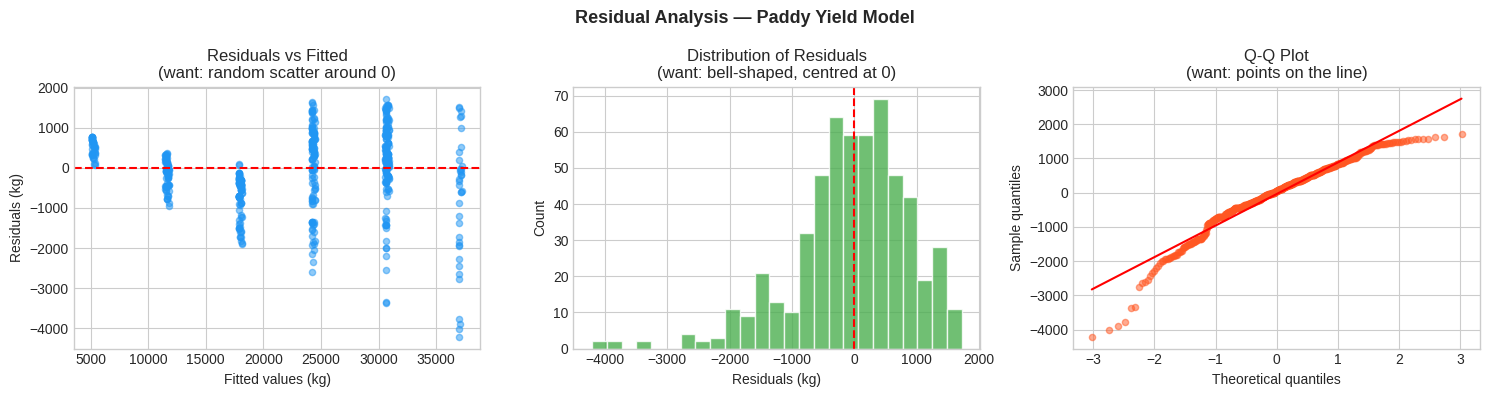

In [26]:
from scipy import stats

residuals = y_test - y_pred
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Residual Analysis — Paddy Yield Model', fontsize=13, fontweight='bold')

# Plot 1 Residuals vs Fitted
ax = axes[0]
ax.scatter(y_pred, residuals, alpha=0.5, s=20, color='#2196F3')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted values (kg)')
ax.set_ylabel('Residuals (kg)')
ax.set_title('Residuals vs Fitted\n(want: random scatter around 0)')

# Plot 2 Distribution of residuals
ax = axes[1]
ax.hist(residuals, bins=25, color='#4CAF50', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Residuals (kg)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals\n(want: bell-shaped, centred at 0)')

# Plot 3 — Q-Q plot
ax = axes[2]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, s=20, color='#FF5722')
ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q-Q Plot\n(want: points on the line)')

plt.tight_layout()
plt.show()

In [28]:
# Check for overfitting compare train vs test performance
y_pred_train = model.predict(X_train_selected)

R2_train = r2_score(y_train, y_pred_train)
R2_test  = r2_score(y_test, y_pred)

print(f'R² Train : {R2_train:.4f}')
print(f'R² Test  : {R2_test:.4f}')
print(f'Gap      : {abs(R2_train - R2_test):.4f}')
print()
if abs(R2_train - R2_test) < 0.02:
    print('✅ No overfitting as train and test performance are very close')
else:
    print('⚠️ Possible overfitting as significant gap between train and test')

R² Train : 0.9895
R² Test  : 0.9891
Gap      : 0.0005

✅ No overfitting as train and test performance are very close


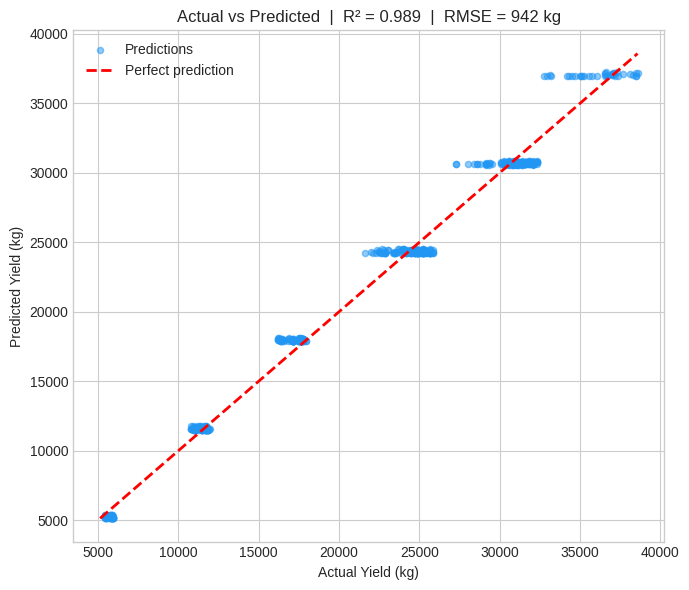

In [29]:
#Actual vs Predicted plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=20, color='#2196F3', label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Yield (kg)')
plt.ylabel('Predicted Yield (kg)')
plt.title(f'Actual vs Predicted  |  R² = {R2:.3f}  |  RMSE = {RMSE:,.0f} kg')
plt.legend()
plt.tight_layout()
plt.show()

## Summary — Paddy Crop Yield Prediction

### Pipeline
Raw data (45 features) → EDA → Encoding (63 features) → Outlier removal → VIF (10 features) → RFE (5 features) → Linear Regression → Evaluation

---

### Key EDA Findings
- Farm size (Hectares) is the dominant driver of yield, all farm inputs correlate at 0.995 with target
- Weather features (temperature, rainfall, humidity) have near-zero correlation with yield
- Categorical features (Variety, Soil Types, Agriblock, Nursery) show identical average yield across categories : minimal impact
- Bimodal yield distribution reveals two farm groups: small farms (5,000–12,000 kg) and large farms (30,000–38,000 kg)
- No missing values, one outlier feature (Wind Speed D61–D90) capped using IQR

---

### Feature Engineering
| Step | Features | Reason |
|------|----------|--------|
| Raw | 45 | Original dataset |
| After encoding | 63 | One-hot encoding added columns |
| After VIF | 10 | Removed 53 multicollinear features (VIF > 10) |
| After RFE | 5 | Selected 5 most impactful features |

**Final 5 features:** Hectares, Variety_delux ponni, Wind Direction_D91_D120_NW, Wind Direction_D91_D120_S, Wind Direction_D91_D120_SSE

---

### Model Performance
| Metric | Value | Interpretation |
|--------|-------|----------------|
| R² | 0.9891 | Model explains 98.9% of yield variance |
| RMSE | 942 kg | Typical prediction error |
| MAE | 708 kg | Average prediction off by 708 kg |
| R² Train vs Test | 0.9895 vs 0.9891 | Gap = 0.0005 so no overfitting |

---

### Key Insights
- Every additional hectare adds **6,364 kg** of yield, farm size drives everything
- Delux ponni variety adds **178 kg** over reference variety, minor but real
- Wind direction in final growth stage (D91–D120) has small but measurable effect
- Residuals are random, normally distributed, all Linear Regression assumptions satisfied
- Model is interpretable, accurate, and generalises well to unseen data